In [1]:
#git clone https://github.com/rschurko/DESPERATE.git

In [2]:
!pip install PyWavelets
!pip install "cvxpy==1.4.1"
!pip install "numpy<2.0"


Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable


In [3]:
import sys
desperate_path = "/home/kinkini/Downloads/Chemistry/NMR/nmr_test_cases/libraries/DESPERATE/functions"

if desperate_path not in sys.path:
    sys.path.insert(0, desperate_path)


In [4]:
#download from here https://github.com/rschurko/DESPERATE/blob/master/simulations/Sn_CPMG_id.fid
Sn_CPMG_id = '/home/kinkini/Downloads/Chemistry/NMR/nmr_test_cases/global_test_data/Sn_CPMG_id.fid'

0
1
2


findfont: Font family 'arial' not found.


3
4
5
+----------+-----------+---------+----------+
| SNRpp_in | SNRpp_out | SSIM_in | SSIM_out |
+----------+-----------+---------+----------+
|  152.0   |  4451.5   | 0.9985  |  0.9997  |
|   68.6   |  4171.5   | 0.9948  |  0.9988  |
|   51.3   |  1451.2   | 0.9890  |  0.9960  |
|   29.6   |  1192.6   | 0.9779  |  0.9788  |
|   22.2   |   567.1   | 0.9477  |  0.9735  |
|   17.2   |  1047.0   | 0.9220  |  0.9581  |
+----------+-----------+---------+----------+
Finished!
-- 0.61943 s Run Time --


findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font f

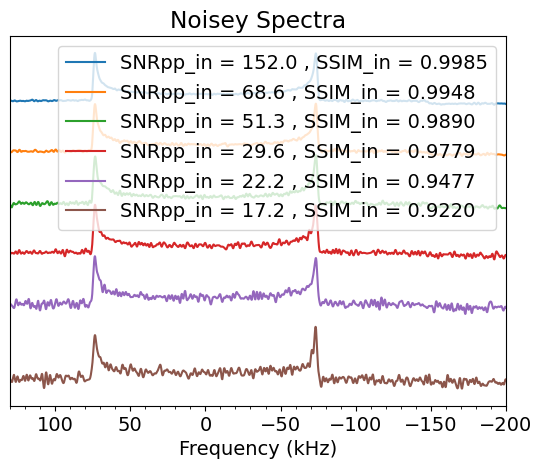

findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font family 'arial' not found.
findfont: Font f

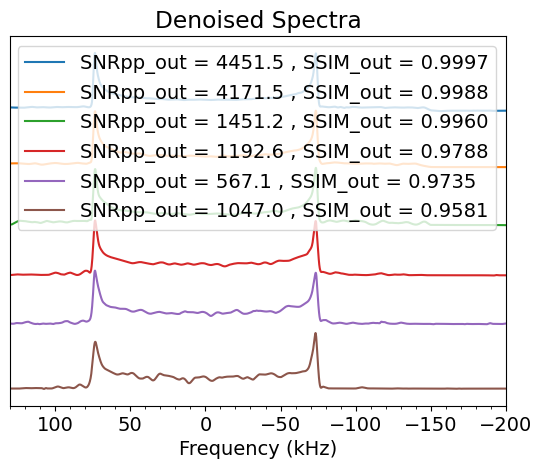

In [5]:
# this is taken from https://github.com/rschurko/DESPERATE/blob/master/simulations/simpson.py

# -*- coding: utf-8 -*-
import sys
import numpy as np
import functions as proc
import simpson as simproc
import wavelet_denoise as wave
import matplotlib.pyplot as plt
import matplotlib as mpl
import time
from tabulate import tabulate

start_time = time.time()

ph = [558.67, 92160.09, 0, 0]
zf = 2**14 #optional larger 0-fill

##Get reference with no noise
R2 = 0.02 #fake R2 global, unitless
name = Sn_CPMG_id
fidref,SW = simproc.read(name, lb=R2, plot='no') #no noise ref for SSIM
#sys.exit()
fidref= simproc.coadd(fidref, 512, 50)
specref = proc.phase(proc.fft(fidref,zf),ph)

noisey = [ 0.05, 0.1, 0.15, 0.2, 0.3, 0.4]
kk = len(noisey)

freq = simproc.freqaxis(specref,SW)
a = simproc.nearest(freq,-73.2395) ##Allows me to change ZF and retain peak indices
b = simproc.nearest(freq,145.514)

j = int(len(specref)/2)

snrpin = np.zeros(kk)
snrpout = np.zeros(kk)
SSIMin = np.zeros(kk)
SSIMout = np.zeros(kk)
SSIMinlow = np.zeros(kk)
SSIMoutlow = np.zeros(kk)
specrecon = np.zeros((len(specref),kk),dtype='complex64')
specin = np.zeros((len(specref),kk),dtype='complex64')
for i in range(kk):
    fidn,SW = simproc.read(name, lb=R2, plot='no') #noisey FID
    fid = simproc.noise(fidn,noisey[i])
    fid = simproc.coadd(fid, 512, 50)
    spec = proc.phase(proc.fft(fid,zf),ph)
    specin[:,i] = spec
    
    snrpin[i] = simproc.snrp(spec,a,b) 
    SSIMin[i] = simproc.ssim(specref,spec) 
    SSIMinlow[i] = simproc.ssim(specref[j:],spec[j:])

    specrecon[:,i], coeffin, coeffs = wave.wavelet_denoise(7, np.real(spec), 0, wave = 'bior2.2', threshold = 'mod', alpha = 0)

    SSIMout[i] = simproc.ssim(specref,specrecon[:,i])
    SSIMoutlow[i] = simproc.ssim(specref[j:],specrecon[j:,i])
    snrpout[i] = simproc.snrp(specrecon[:,i],a,b)
    
    print(i)
    del fid

##Plotting
mpl.rcParams['font.family'] = "arial"
mpl.rcParams['font.size'] = 14

plt.figure(1)
for i in range(len(snrpin)):
    plt.plot(freq,np.flipud(np.real(specin[:,i]) - i*np.max(np.real(specin[:,i]))), label = 'SNRpp_in = %.1f , SSIM_in = %.4f' % (snrpin[i],SSIMin[i]))
plt.legend(loc='upper right')
plt.title('Noisey Spectra')
plt.gca().invert_xaxis()
plt.xlabel('Frequency (kHz)')
plt.xlim((130,-200))
plt.yticks([])
plt.legend(loc='upper right')
plt.minorticks_on()

plt.figure(2)
for i in range(len(snrpin)):
    plt.plot(freq,np.flipud(np.real(specrecon[:,i]) - i*np.max(np.real(specrecon[:,i]))), label = 'SNRpp_out = %.1f , SSIM_out = %.4f' % (snrpout[i],SSIMout[i]))
plt.legend(loc='upper right')
plt.title('Denoised Spectra')
plt.gca().invert_xaxis()
plt.xlabel('Frequency (kHz)')
plt.xlim((130,-200))
plt.yticks([])
plt.legend(loc='upper right')
plt.minorticks_on()


##Table of results
data=[]
for i in range(len(snrpin)):
    data.append( ["%.1f"%snrpin[i],"%.1f"%snrpout[i], "%.4f"%SSIMin[i], "%.4f"%SSIMout[i]] )
# create header
head = ['SNRpp_in','SNRpp_out', 'SSIM_in', 'SSIM_out', 'SSIM_in_low', 'SSIM_out_low']
# display table
print(tabulate(data, headers=head, tablefmt="pretty", floatfmt="5.4f"))

print('Finished!')
print("-- %5.5f s Run Time --" % (time.time() - start_time))